# Deep Learning: II

*Davide Gerosa (Milano-Bicocca)* 

##### Reading/watching

- [Textbook](http://press.princeton.edu/titles/10159.html) Chapter 9.
- [Neural Networks Demystified](https://www.youtube.com/watch?v=bxe2T-V8XRs&list=PLiaHhY2iBX9hdHaRr6b7XevZtgZRa1PoU&ab_channel=WelchLabs) youtube playlist.

##### Dig deeper:

- ["Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow", Aurelien Geron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/). 
-  ["Neural Networks and Deep Learning"](http://neuralnetworksanddeeplearning.com/index.html). Free online book!
- Many many blogs and videos. Deep learning as a million applications that go well beyond astrophysics. There is truly excellent content accessibile out there with just a tiny bit of googling.

This course is based on previous work by many people. See [here]((https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/README.md) for credits.

---

Before starting today, let's install the two big Deep Learning packages out there. [Tensorflow](https://www.tensorflow.org/) and [PyTorch](https://pytorch.org/)-- the rivalry essentially boils down to Google versus Facebook. These are the public deep learning implementation of giant companies. If you apply for a data-science job in industry knowing one of these tools might be the most useful thing for you to have learned in this class.


Crucially, these libraries work with automatic differentiation and this is the very core of these libraries. Remind that the automatic differentiation idea is that you make derivaties by breaking operations at the chip level. We won't call the autodiff modules explicitely but they are [tensorflow.GradientTape](https://www.tensorflow.org/api_docs/python/tf/GradientTape) and [torch.autograd](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html).

**My personal experience** I find TensorFlow more customizable and there are excellent tutorials around. Tensorflow is somewhat less readable though, while coding in Pytorch is a more "pythonic" experience (some operations feel more natural). But it's really a matter of taste here... In my research group we pusblished with both.

In [1]:
# !pip install --upgrade pip
# !pip3 install tensorflow
# !pip3 install torch torchvision

#### Keras

Tensorflow is the low level infrastructure. Keras is a wrapper for Tensorflow

**[Keras](https://keras.io/)** is a deep learning API. Essentially it is Scikit-Learn for deep neural networks.

In short, for neural networks:

> numpy -> tensorflow

> sklearn -> keras

In the same way that you can build a linear regression algorithm in numpy without using sklearn, you can build a neural network algorithm (not to mention linear regression) in tensorflow without using keras.  But just as sklearn makes our life easier, so too does keras.

## Photo-z with deep learning <a class="anchor" id="one"></a>

An important problem in galaxy imaging is being able to use observed galaxy color data to estimate its redshift instead of going to a telescope and acquiring the spectrum which is more difficult and expensive. This is sometimes called "photo-z". Now, on your humble computer, you will build a deep neural network that is trained on a sample of SDSS galaxy color data. You'll see that `pytorch` makes this quite easy. So you have a sample of galaxies with the known redshift, you need to predict the redshift of new sample: it's a regression problem. This is a pytorch approach

In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata

from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results

from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

C:\Anaconda\envs\new_env\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


Read in and prepare the SDSS data.

In [3]:
# Fetch and prepare the data
data = fetch_sdss_specgals()

# put magnitudes into array
# normalize to zero mean and unit variance for easier training
datanormed = np.zeros((len(data), 6), 
                      dtype=np.float32)
for i, band in enumerate(['u', 'g', 'r', 'i', 'z']):
    band = 'modelMag_' + band
    datanormed[:, i] = ((data[band] - data[band].mean()) / 
                        data[band].std())

# put redshifts into array
datanormed[:, 5] = data['z']

Let's define a little helper class that will make our network. It is initialized with a given number of neurons (nhidden) in the single hidden layer. These neurons in the hidden layer connect to $5$ input variables (colors) and spits out 1 variable (redshift). The first synapsis will go from 5 to 4 and the output synapsis goes from 4 to 1 which is the one value I want to predict. The forward model grabs output from the hidden layer, applies a relu activation function and passes it along.

In [4]:
# define structure of neural net
class Net(nn.Module):
    def __init__(self, nhidden):
        super(Net, self).__init__()
        self.fc_h = nn.Linear(5, nhidden)
        self.fc_o = nn.Linear(nhidden, 1)

    def forward(self, x):
        h = F.relu(self.fc_h(x))
        z = self.fc_o(h)
        return z

Do a train-test split on the data. Remind that the batch size means that the network will see 128 datapoints and do one pass of gradient descent. It sees batches of 128 size for each gradient descent optimization.

In [5]:
# split data into 9:1 train:test
dataset = torchdata.TensorDataset(torch.tensor(datanormed[:, 0:5]),
                                  torch.tensor(datanormed[:, 5]).view(-1, 1))
# get the 10% of the data as test set
trainnum = datanormed.shape[0] // 10 * 9
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, datanormed.shape[0] - trainnum])
#This is the object you pass to your model training loop — it efficiently feeds data to the model.
traindataloader = torchdata.DataLoader(traindata, 
                                       batch_size=128, 
                                       shuffle=True)

Define a function to train the neural network. This looks like a lot of code, but the first block is the key. The network will have $4$ neurons in the hidden layer, and will use stochastic gradient descent to train the weights and biases.

As for the scheduler, it adapts the learning rate. After 5 epochs, start decreasing the learning rate. The idea is that I go around with coarse steps at the beginning and once that I'm around the solution, I refine the solution.

Perform 50 epochs: the network sees the entire data set 50 times. Be careful: there are more than 50 iterations of the gradient descent because the gradient descent is optimized every batch.
Backpropagation to compute the derivatives using autodifferentiation. Once that I have the derivatives, I take a step in the optimization that is step in gradient descent in the direction of the steeepest grad desc with step given by the learning rate.

In [6]:
@pickle_results('NNphotoz.pkl')
def train_NN():
    # 4 hidden layers
    model = Net(4)
    # MSE loss. This is the loss function which is mean squared error
    criterion = torch.nn.MSELoss(reduction='sum') 
    # stochastic gradient descent. Optimizer with learning rate
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001) 
    # Adaptive learning rate... after 5 epochs start decreasing the learning rate
    # The idea is that I go around with coarse steps at the beginning and once that I'm
    # around the solution, I refine the solution
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                           verbose=True, 
                                                           patience=5, 
                                                           threshold=1e-3)

    min_valid_loss = float('inf')
    badepochs = 0
    # perform 50 epochs: the network sees the data 50 times
    for t in range(50):
        train_loss = 0
        for i, databatch in enumerate(traindataloader, 0):
            #The following lines are the core of the pytorch approach
            photometry, redshifts = databatch
            optimizer.zero_grad() # Initalize optimizer (biases and weights)
            z_pred = model(photometry) # Predictions (this means going forward in the network)
            loss = criterion(z_pred, redshifts) # Compute loss
            loss.backward() # Backpropagation to compute the gradients
            optimizer.step() # Step in gradient descent in the direction of the steeepest grad desc
            # with step given by the learning rate
            train_loss += loss.item() # Update loss

        with torch.no_grad():
            photometry = testdata[:][0]
            redshifts = testdata[:][1]
            z_pred = model(photometry)
            valid_loss = criterion(z_pred, redshifts)
            if t % 10 == 0:
                print('Epoch %3i: train loss %0.3e validation loss %0.3e' % (t, \
                        train_loss / len(traindata), valid_loss / len(testdata)))
            # stop training if validation loss has not fallen in 10 epochs
            if valid_loss > min_valid_loss*(1-1e-3):
                badepochs += 1
            else:
                min_valid_loss = valid_loss
                badepochs = 0
            if badepochs == 10:
                print('Finished training')
                break
        scheduler.step(valid_loss)
    return model

Let's train this thing. It should take about five minutes. 

In [7]:
model = train_NN()

@pickle_results: computing results and saving to 'NNphotoz.pkl'


C:\Anaconda\envs\new_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   0: train loss 1.269e-03 validation loss 8.438e-04
Epoch  10: train loss 6.489e-04 validation loss 6.403e-04
Epoch  20: train loss 6.235e-04 validation loss 6.126e-04
Epoch  30: train loss 6.132e-04 validation loss 6.026e-04
Epoch  40: train loss 5.951e-04 validation loss 5.806e-04


In [8]:
print(model)

Net(
  (fc_h): Linear(in_features=5, out_features=4, bias=True)
  (fc_o): Linear(in_features=4, out_features=1, bias=True)
)


Plot the results.

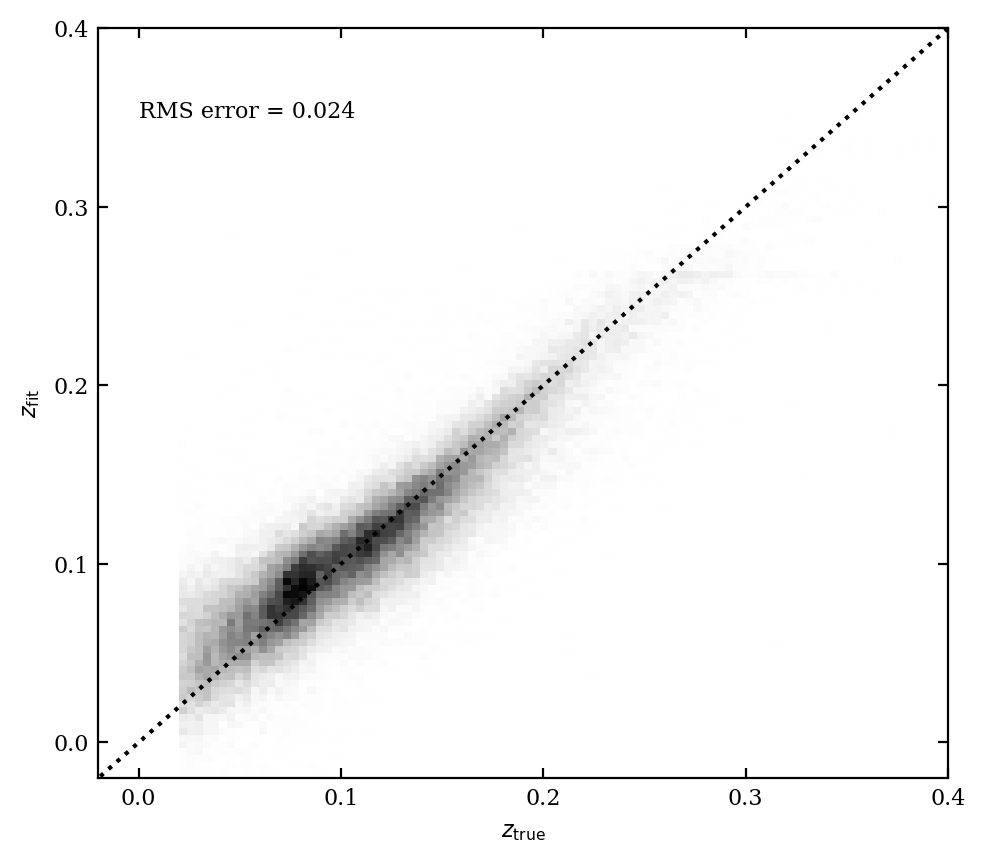

In [9]:
# plot the results
with torch.no_grad():
    photometry = testdata[:][0]
    redshifts = testdata[:][1]
    z_pred = model(photometry)
    fig = plt.figure(figsize=(5, 5))
    fig.subplots_adjust(wspace=0.25,
                        left=0.1, right=0.95,
                        bottom=0.15, top=0.9)

    ax = plt.axes()
    H, zs_bins, zp_bins = np.histogram2d(redshifts.numpy().flatten(), 
                                         z_pred.numpy().flatten(), 151)
    ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
               extent=[zs_bins[0], zs_bins[-1], zp_bins[0], zp_bins[-1]],
               cmap=plt.cm.binary)
    ax.plot([-0.1, 0.4], [-0.1, 0.4], ':k')
    rms = np.sqrt(np.mean((z_pred-redshifts).numpy()**2))
    
    ax.text(0, 0.35, 'RMS error = %0.3f' % np.sqrt(np.mean((z_pred-
                                                            redshifts).numpy()**2)))
    ax.set_xlim(-0.02, 0.4001)
    ax.set_ylim(-0.02, 0.4001)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    
    ax.set_xlabel(r'$z_{\rm true}$')
    ax.set_ylabel(r'$z_{\rm fit}$')
    
    plt.show()

Not bad at all! Still, this was a relatively simple fully-connected network (each neuron is connected to every previous and subsequent neurons). Other problems will require more complexity...

## Convolutional Neural Networks (CNNs) <a class="anchor" id="two"></a>

Recent interest in neural networks surged in 2012 when a team using a deep **[convolutional neural network (CNN)](https://en.wikipedia.org/wiki/Convolutional_neural_network)** acheived record results classifying objects in the [ImageNet](http://image-net.org/) data set.

If you naively apply a multi-layer perceptron to an image, the first thing to do would be unravel the array of pixels into a long one-dimensional array (much like we did for the digits images a few weeks ago). That's fine but it's neglecting precious information, namely that pixels next to each other are correlated.

The idea behind CNNs is inspired by human visual perception. ***Each neuron in your visual cortex doesn't "see" all of what your eye can see at once*** and some neurons are more sensitive to one pattern over another (e.g., horizontal lines vs. vertical lines). The way this is implemented in numbers is through convolution  

Moreover, the simplest deeply connected neural networks would choke on "real" data which has far more than 28x28 pixels, and would require following tens of millions of connections. So we use a combination of 
- "convolution"
- "pooling" 

to reduce the dimensionality of the data first.

In other words. A CNN works such that you have an image and you have some operations that work on kernels so something that look only on the white square part of the image and passes it along. Then you have some max pooling operations to reduce the data (is a data compression operation) and finally a fully connected layer that predicts. 

![Ivezic Figure 9.19](https://www.astroml.org/_images/fig_cnn_1.png)

### Convolutional Layers

In a convolutional layer, each neuron is not connected to each neuron in the previous layer, but only those that are within its "field of view" as defined by a kernel (filter).  We slide the kernel over the input layer and the value in the next layer depends only on those pixels. So, the kernel is the orange 3x3 matrix while the crosses are the weights and biases that gets optimized by the network. This makes sure that an element of the transformed image is actually made up of a combination of the original pixel and what is close by. Thus the idea is that each neuron has a short field of view: is like a microscope that looks in a part of the data set and processes only that 

This solves the problem that you have when you unravel an image that is that you lose information. Indeed, two rows that were close to each other, now end up very far. So you would missing out correlation which occures very naturally in images. Indeed, if one pixel is white, is likely that the one below is going to be withe-ish or contrarly if there is a strong contrast, that is a feature that you want to learn that you miss when you unravel. Thus, this convolutional layer solves this problem.

![](https://miro.medium.com/max/4800/1*GcI7G-JLAQiEoCON7xFbhg.gif)

Here's another perspective that helps to visualize going from one layer to the next.

![Convolution example](https://docs-assets.developer.apple.com/published/09348c5368/a55b1477-4f79-4221-8aa1-ab3ae9f01f89.png)

Choosing a filter (kernel) with a certain pattern can help recognize certain types of features (like horizontal aor vertical lines).

![vertical filter](https://miro.medium.com/max/1338/1*7IEbBib7Yc7qST5IGQoYXA.jpeg)

![horizontal filter](https://miro.medium.com/max/1238/1*PSSAaH2pZbl5bK3Ef_zk4A.jpeg)

The purpose of the convolutional layers is really to capture high-level features in the images, like edges.

Indeed the weights and biases of the convolutional layer are the things that get optimized. In practice this means that one convolutional layer takes care of learning vertical structures and another one takes care of horizontal structures.


This reminds me of polarized light, which is personally how I visualize CNNs in my mind...




### Pooling Layers

It turns out that after the convolution you still need some sort of pooling operations which is a data compression scheme. This helps the network focus on important features. A common one is Max Pool.

It is common to follow the convolutional layer by a so-called "pooling layer", essentially to reduce the amount of data that needs to be processed.  The full architechture of a CNN might look something like this:

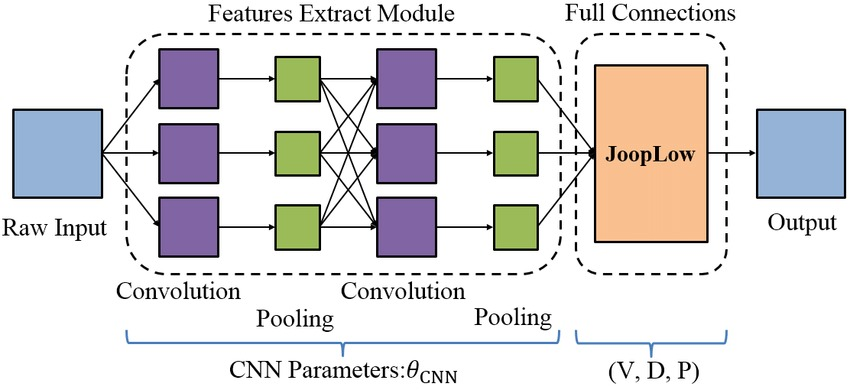

Where the pooling layers are reducing the number of pixels by averaging, summing, taking the max, etc. "**Max Pool**" is the most popular, and literally corresponds to taking the maximum of the convolution. In the case below, the kernel is 2x2 and takes the max of that. This helps filter out useless information.

The combination of convolution and pooling helps the network to figure out features and structures as you go along. Then, once you are done, a fully connected network takes care of the actual predictions.

![Pooling example](https://miro.medium.com/max/1000/1*ydNsGDxMldAiq7b96GDQwg.jpeg)

or another way to see this is...

![](https://miro.medium.com/max/792/1*uoWYsCV5vBU8SHFPAPao-w.gif)

When we are done with convolution and pooling, the output gets fed into a regular, fully connected neural network that outputs the predictions.

- This is clearly much more sophisticated than our basic fully-connected multi-layer perceptron. "Deep" networks consist of tens of layers with thousands of neurons. 

- Sparse layers or convolutional layers in a deep network contain a large number of hidden nodes but very few synapses. The sparseness arises from the relatively small size of a typical convolution kernel (15x15 is a large kernel), so a hidden node representing one output of the convolution is connected to only a few input nodes. Compare this to our previous perceptron, in which every hidden node was connected to every input node.

- In other words: there is a strong contrast compared to the fully connected network that we've seen before and this CNN is called also a sparse network. Indeed, in a convolution layer, each node (that is a pixel of the transformed image) is connected only to a subset of the dataset given by the field of view (basically the width of the kernel that in the example above is a 3x3 matrix) so with 9 data points and not with all the features. This is in contrast with what we had before where each neuron is connected with all the neurons of the previous layer and passes the information to all the neurons of the following layer. In this case, though, there are lots and lots of missing connections so it's an extremely sparse network: of all the many connections that you could have you have only the number of connections given by the field of view of the network which can be optimized with cross validation along with with which type of kernel you want to apply.

- This sparsity helps the network concentrating on the key features.

- Even though the total number of connections is greatly reduced in the sparse layers, the total number of nodes and connections in a modern deep network is still enormous. Luckily, training these networks turns out to be a great task for GPU acceleration.


For further study, there are lots of resources for CNNs online.  For example, see
https://medium.com/analytics-vidhya/convolutional-neural-networks-cnn-explained-step-by-step-69137a54e5e7

The following cells are from Geron, Chapter 10, see 
https://github.com/ageron/handson-ml2/blob/master/10_neural_nets_with_keras.ipynb

We'll start by introducing the **Fashion MNIST data set**. The next cells load the data, define test, trainging, and validation sets; normalize the data; display an example image; list the possible target values ($y$), and show a 4x10 grid of examples. In this case the number of features is given by the number of pixels while the labels are the name of the clothing but note that we will keep the actual spatial structure of the images and will write $[28,28]$ and not [$28\times28$]

Note the explicit splitting in train, validation and test set.

In [17]:
from tensorflow import keras

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(X_train_full.shape)
print(X_test.shape)

#The first 5,000 images of the training set are used as a validation set (X_valid, y_valid).
#The remaining 55,000 are used for training (X_train, y_train).
#Dividing by 255.0 scales pixel values from [0, 255] to [0, 1], which helps neural networks train more efficiently.
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)


This data set is a huge collection of images of items of clothing.

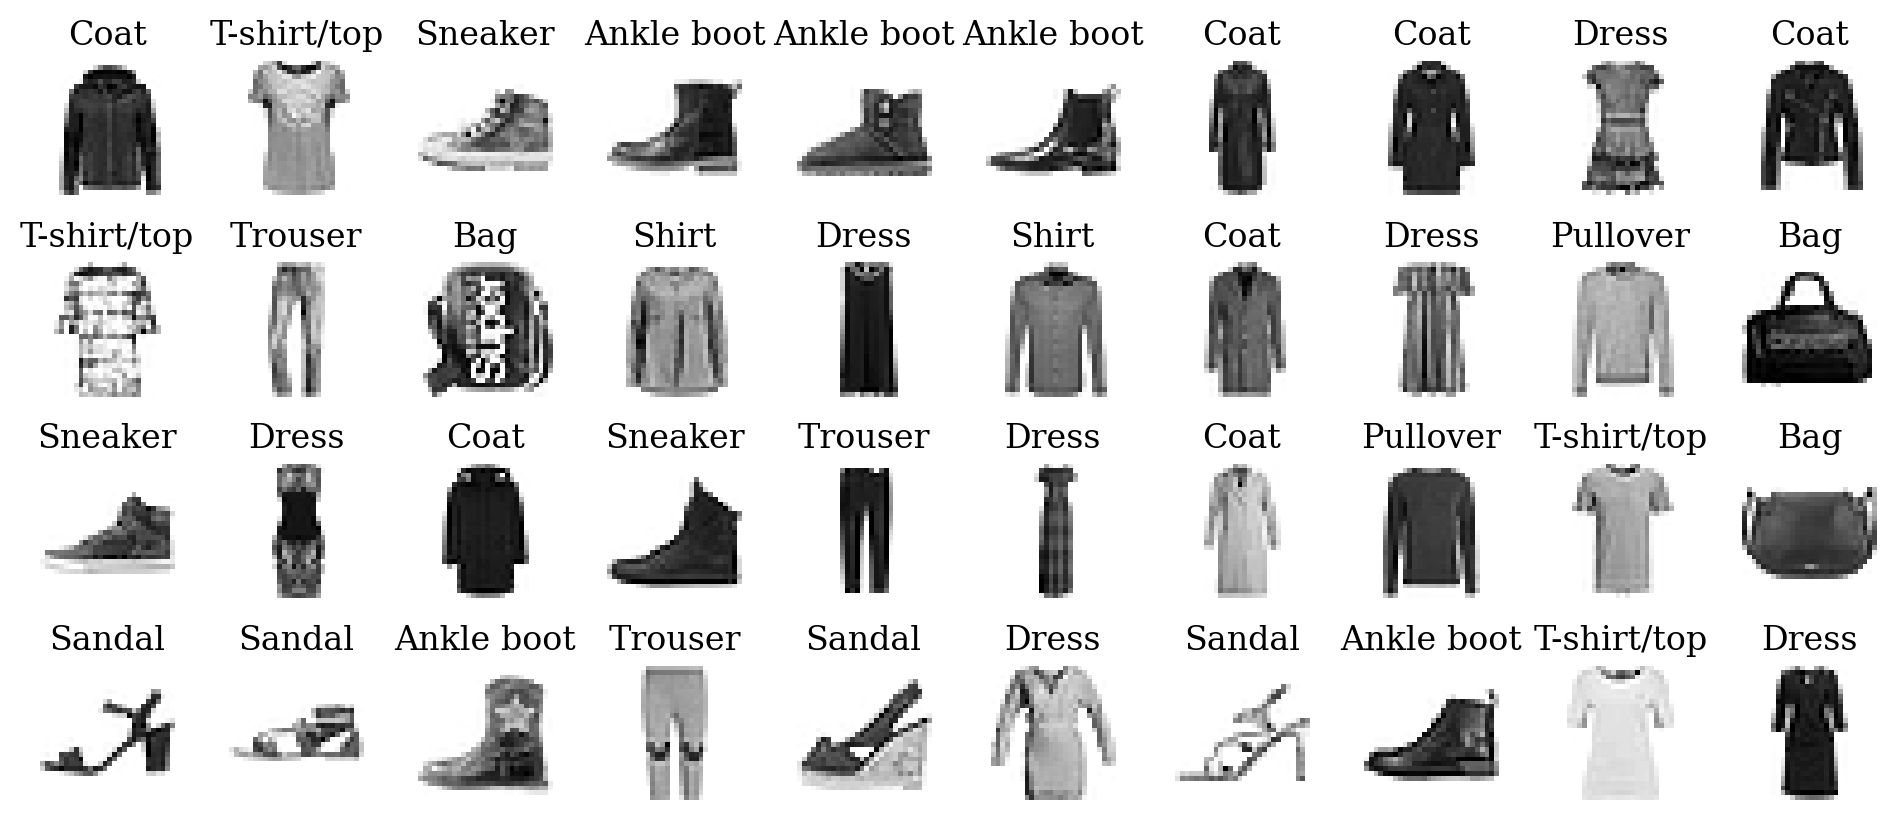

In [11]:
# Let's make a list of class names that we can refer to.
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Plot 4x10 array of images from the Fashion MNIST database
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest", origin='upper')
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

We'll use `tensorflow` on this data set, through it's handy API `keras`. Since these are images and we want to preserve contextual information like edges, we'll build a CNN.

In [12]:
import tensorflow as tf

keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

Normalize and prepare the data to pass into a network. This is particularly important in deep learning since activation function are non linear around 0 and if I don't preprocess, nothing works.

In [13]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std


# Need to reshape for CNN
X_train = X_train[:, :, :, np.newaxis]
X_valid = X_valid[:,  :, :, np.newaxis]
X_test = X_test[:, :, :, np.newaxis]

print(len(X_train))
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

55000
(55000, 28, 28, 1)
(5000, 28, 28, 1)
(10000, 28, 28, 1)


The next cell looks like a lot, but really it is just a sequential declaration of different types of layer in the network. It is a combination of **2D Convolution layers** (feature finding), **Max Pooling layers** (data reduction), followed by some **Dense layers** (fully-connected layers at the end of the network for classification) and some **Dropout** incorporated to strengthen the overall network and make sure all the neurons are actually pulling their weight and acts as a sort of regularization. Note also that the convolution kernel_size is 7 and 3 then. Also the pool_size has a field of view of 2x2. Up to .flatten() I've learned the features. Now I've individual features that come from the correlations of the pixel and now I can flatten them. In other words I can forget the 2D structure and that's ok because I've learned the structure already and then go into a fully connected network. Note that I'm compressing the stages from 128 to 10 which is the final classification stage. I've 10 classes down the line so the this thing is predicting the probability that each sample belongs to each class.

In [14]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[28, 28, 1]),
    keras.layers.Conv2D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),  
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])   

C:\Anaconda\envs\new_env\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [15]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

None


**That's right...your CNN has ~1.5 million parameters that you are going to try to optimize on your laptop...**

We'll only go through one epoch of optimization, but hopefully that will be enough to get us above $50\%$ accuracy.
We see that the validation loss is much lower than the training loss so this means that I'm underfitting so we should really go for longer meaning for a higher number of epochs since this is just one pass of the data.

In [16]:
#### This may take a while! Hopefully no more than 5 minutes for 1 epoch.
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=1, validation_data=(X_valid, y_valid))

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 158s 91ms/step - accuracy: 0.6458 - loss: 1.0085 - val_accuracy: 0.8566 - val_loss: 0.3798


Predict values for first 3 test objects

In [18]:
X_new = X_test[:3]
y_proba = model.predict(X_new).round(2)
print(y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
[[0.08 0.03 0.06 0.06 0.09 0.13 0.1  0.16 0.22 0.08]
 [0.01 0.   0.68 0.   0.12 0.   0.18 0.   0.   0.  ]
 [0.   0.99 0.   0.01 0.   0.   0.   0.   0.   0.  ]]


So, you can see that the output is a probability that the object belongs to each class (which has to sum to 1 across all the classes).  If we just want an "answer", we assign it to the class with the highest probability (done here with `predict_classes`).

In [22]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
print(y_pred)
print(np.array(class_names)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[8 2 1]
['Bag' 'Pullover' 'Trouser']


Let's plot those and see if the predictions make sense.

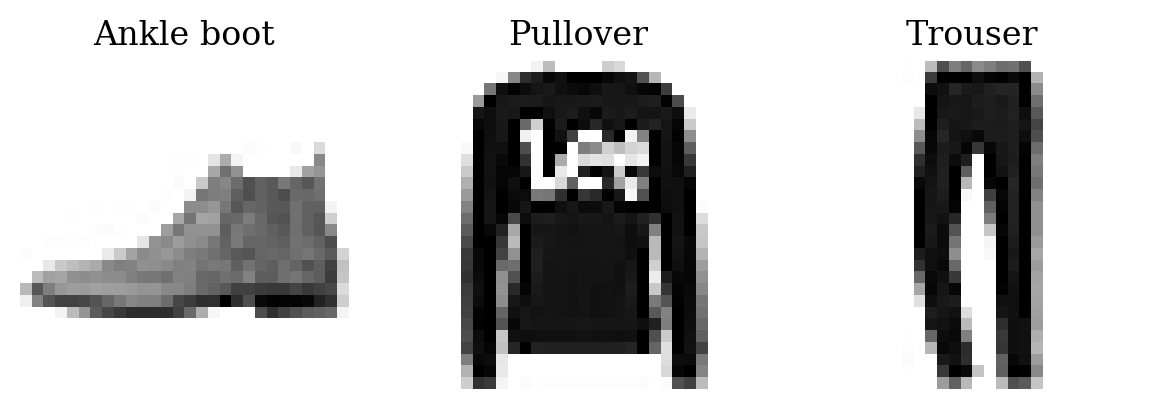

In [23]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest", origin='upper')
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Note that after you fit your model, you can save it and reload it at some later time (which is good because some models might take hours or days to train!)

In [24]:
# Save model
model.save("my_keras_model.h5")

# Reload model
model = keras.models.load_model("my_keras_model.h5")

Let's predict the values for 10 random objects. Display them with their actual labels first, then predict and display the predictions.

In [25]:
idx10 = np.random.choice(np.arange(len(y_test)), size=10, replace=False)
X_new = X_test[idx10]
y_pred = np.argmax(model.predict(X_new), axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


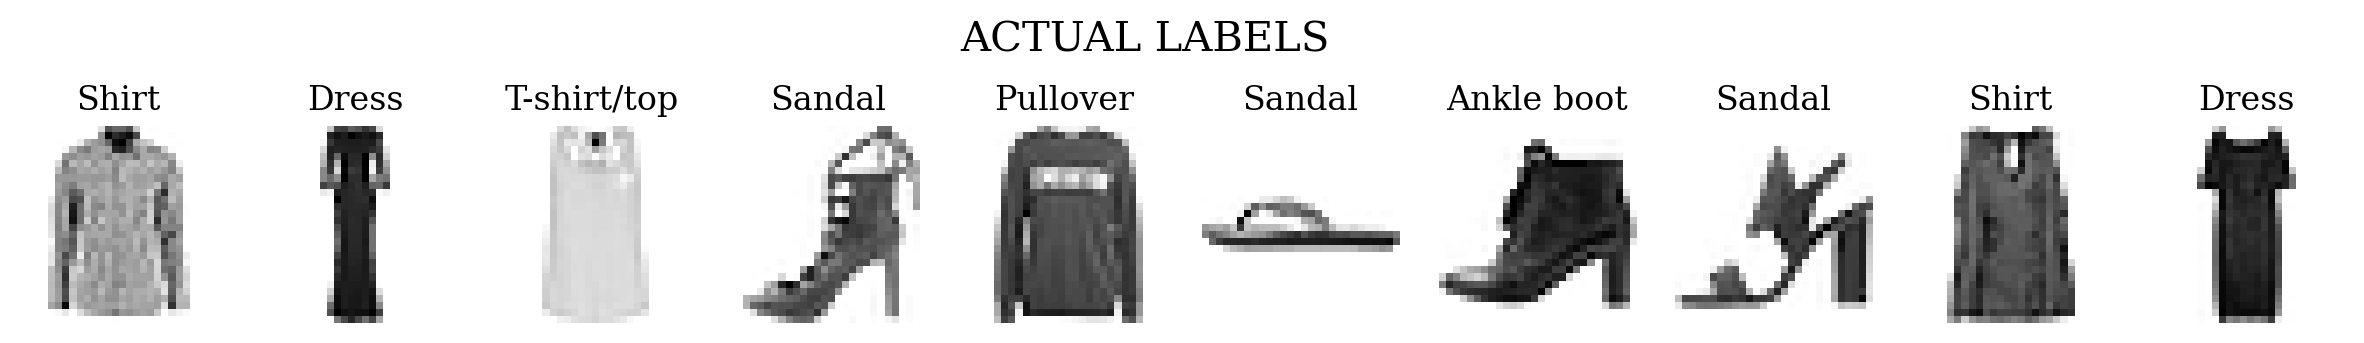

In [26]:
#Correct answers (y_test)
plt.figure(figsize=(15, 5))
for index, image in enumerate(X_new):
    plt.subplot(1, 10, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest", origin='upper')
    plt.axis('off')
    plt.title(class_names[y_test[idx10[index]]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle('ACTUAL LABELS',y=0.7,fontsize=15)
plt.show()

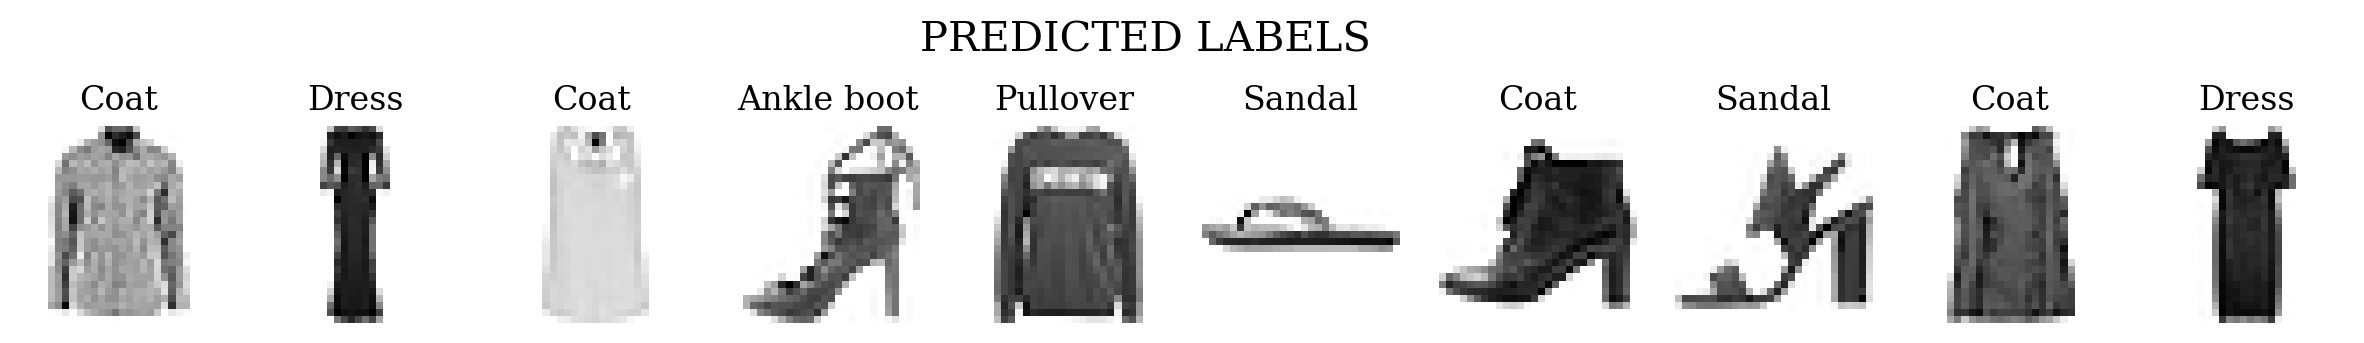

In [27]:
#Predicted answers (y_pred)
plt.figure(figsize=(15, 5))
for index, image in enumerate(X_new):
    plt.subplot(1, 10, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest", origin='upper')
    plt.axis('off')
    plt.title(class_names[y_pred[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle('PREDICTED LABELS',y=0.7,fontsize=15)
plt.show()

Not too shabby! And I've only done 1 epoch!

To sum up: in general convolution works well when you have correlation between features (images, sounds, times series, spectra) 

## Autoencoders <a class="anchor" id="three"></a>

**Autoencoders are neural networks that copy their input to their output, but after passing the data through a compression bottleneck**. For example if there are 28x28 = 784 inputs, there will also be 784 outputs, but there will be one or more (odd, but symmetric) hidden layers with fewer neuron than that.

***Therefore the encoder layers learn a compressed representation of the data, with the decoder layers transforming the encodings back to the full data dimensionality.*** 

For example see 

![autoencoder structure](https://miro.medium.com/max/1400/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png)

from
https://towardsdatascience.com/applied-deep-learning-part-3-autoencoders-1c083af4d798

The idea is that you have many inputs (think of an image, this means many pixels) and send them through an econder stage which progressively decreases the number of neurons. This forces the network to concentrate on the most important information. Then you have a decoding part where you reexpand the network either simmetricaly or not where the output layer has the same number of features of the input layer. Thus, the encoder needs to compress may pixels into few pixels and it's more likely to learn the features that are stronger, washing away the noise or less important data. Then the decoder rexpands into the original space without carrying the noise.

**This is the deep-learning approach to the problem of dimensionality reduction.**  You can think of an autoencoder as doing PCA with a neural network -- breaking our data down into the only the most important features that we actually *need* (finding the intrinsic dimensionality). In fact, if the network uses only linear (or no) activation functions and $L2$ cost function, then we have exactly PCA.  

How might this be useful?  Well, for example we can use it to reconstruct MNIST digits that have had noise added to them:

![autoencoder example](https://miro.medium.com/max/1400/1*SxwRp9i23OM0Up4sEze1QQ@2x.png)

More exciting possibilities are: 

- Using autoencoders for "**unsupervised pretraining**". For example you have data that is only partially labeled (at least not enough to do traditional supervised classification).  We can train an autoencoder on the full data set, then use the encoder part as the base of a regular neural network that is trained on the labeled data that we do have. This is found to be a much more efficient way of initializing weights and biases than starting from random, because you are "cheating" a bit by already figuring out some of the data structure using the autoencoder. See Geron Figure 17.6. In other words: all this deep learning things work with large dataset but in physics often we don't have this luxury because they are expensive. So if you have a short dataset, send it first into something like autoencoder to denoise it and then train that thing like a supervised learning.
- **[Anomaly detection](https://scikit-learn.org/stable/modules/outlier_detection.html)** (remember the old problem of figuring out if two samples are extracted from the same distribution?) e.g. https://towardsdatascience.com/anomaly-detection-with-autoencoder-b4cdce4866a6 and https://towardsdatascience.com/anomaly-detection-using-autoencoders-5b032178a1ea. See also
https://www.pyimagesearch.com/2020/03/02/anomaly-detection-with-keras-tensorflow-and-deep-learning/ and 
https://towardsdatascience.com/autoencoder-neural-network-for-anomaly-detection-with-unlabeled-dataset-af9051a048. I think this is used in cybersecurity.
- Duplicate an image: you have an image and you want another one that looks like it. This autoencoder let's you learn the key features of the image and produce another image

### Variational Autoencoders

A more physics oriented approach to this problem is variational autoencoders which is somehow related to **density estimation**.

More common in astronomy are **variational autoencoders**, partly because the "latent space" (i.e. the compressed representation of the data) that results from a standard autoencoder doesn't necessarily map continuously to the data (e.g., if your training data don't represent the possibilities or span of the full data space). 

We won't go into detail, just realize that these are something that you might try if you were otherwise going to try an autoencoder to tackle your problem. **Instead of the encoder layers compressing the data down to a single point in the "latent space", it is mapped to a continuous distribution** (imagine if PCA gave you a probabilistic compression). The prior on this continuous distribution is a Gaussian with mean and variance. ***Therefore the intuition for variational autoencoders is that the mean vector centers the average encoding of the data point, while the variance samples around this average encoding.*** This allows the encoding and decoding to interpolate much more smoothly across the training data.

The structure is that of the autoencoder. So you compress into fewer things and then you have a layer of random sampling for istance from a gaussian. So you force the network to compress the data into two numbers, a mean and a sigma, sample it so you introduce some randomness and then rexpand to give the initial space. This is like PCA where you neglect something and the reconstruct but this variational layer captures the fluctuations of the generative process.  

![Ivezic Figure 9.21](https://www.astroml.org/_images/fig_vae_1.png)


This one below is an example of a variational autoencoder trained on SDSS spectra using `pytorch`.

In [28]:
from astroML.datasets import sdss_corrected_spectra
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

# Fetch and prepare the data
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

# normalize spectra by integrated flux and subtract out mean, for easier training
spectranorms = np.mean(spectra, axis=1)
normedspectra = spectra / spectranorms[:, None]
meanspectrum = np.mean(normedspectra, axis=0)
normedspectra -= meanspectrum[None, :]

# split data into 3:1 train:test
torch.manual_seed(802)  # seed used for book figure
dataset = torchdata.TensorDataset(torch.tensor(normedspectra))
trainnum = normedspectra.shape[0] // 4 * 3
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, normedspectra.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, batch_size=128, shuffle=True)

Now define the structure of the variational autoencoder. 
- In the top block you can see that the first layer reduces the $1000$-D input down to $250$.
- We then pass to a $2$D mean and variance layer from which the compressed "latent" parameters can be probabilistically drawn. This means that we compressing down from a 1000 flux channels to a 2D compressed representation.
- The decoding layers decompress the sampled latent parameters and scale back up to the full 1000 flux channel dimensions.
- This is a fully connected network. There are 1000 features. I send them through a series of encoding layers and then through two features (mu and variance). The decoding stage do the opposite. The encode operation applies the non linearity and returns mu and logvar. Reparametrize is the random sampling meaning that I extract a random number from mu and sigma. The forward pass is now the encode, random sampling and decode.

In [29]:
# define structure of variation autoencoder
class VAE(nn.Module):
    def __init__(self, nhidden=250):
        super(VAE, self).__init__()

        # encoding layers
        self.encode_fc = nn.Linear(1000, nhidden)
        self.mu        = nn.Linear(nhidden, 2)
        self.logvar    = nn.Linear(nhidden, 2)

        # decoding layers
        self.decode_fc = nn.Linear(2, nhidden)
        self.output    = nn.Linear(nhidden, 1000)

    def encode(self, x):
        h = F.relu(self.encode_fc(x))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def decode(self, z):
        h = F.relu(self.decode_fc(z))
        return self.output(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

The loss is a modified version of the usual MSE, where we use the **Kullback-Leibler divergence** (which is the entropy between distributions) to asses how close the latent parameter distribution is to a Gaussian. The reason to use this loss function in the variational autoencoder is that you're extracting a gaussian number and the network works well if the distribution you are extracting it from is actually gaussian. Basically we are comparing the entropy between the distribution I'm sampling and the gaussian because I design the network with gaussian samples and it works if i'm actually sampling from a gaussian and i let the network optimize towards that. 

In [30]:
# add KL divergence to loss function
def VAEloss(criterion, recon_x, x, mu, logvar):
    return criterion(recon_x, x) - 0.5 * torch.sum(1 + logvar - 
                                                   mu.pow(2) - 
                                                   logvar.exp())

Another large block that is essentially just training the network.

In [31]:
def train_model():
    model = VAE()
    criterion = torch.nn.MSELoss(reduction='sum')
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                           verbose=True, 
                                                           patience=5, 
                                                           threshold=1e-3)

    min_valid_loss = float('inf')
    badepochs = 0
    for t in range(1000):
        train_loss = 0
        for i, databatch in enumerate(traindataloader, 0):
            specbatch = databatch[0]
            optimizer.zero_grad() #initialize
            recon, mu, logvar = model(specbatch) # predict
            loss = VAEloss(criterion, recon, # compute the loss
                           specbatch, mu, logvar)
            loss.backward() #nbackgropagation
            optimizer.step() # take a step in the optimizer
            train_loss += loss.item()

        with torch.no_grad():
            testspec = testdata[:][0]
            recon, mu, logvar = model(testspec)
            valid_loss = VAEloss(criterion, recon, 
                                 testspec, mu, logvar)
            if t % 10 == 0:
                print('Epoch %3i: train loss %6.1f validation loss %6.1f' % \
                        (t, train_loss / len(traindata), valid_loss / len(testdata)))
            # stop training if validation loss has not fallen in 10 epochs
            if valid_loss > min_valid_loss*(1-1e-3):
                badepochs += 1
            else:
                min_valid_loss = valid_loss
                badepochs = 0
            if badepochs == 10:
                print('Finished training')
                break
        scheduler.step(valid_loss)
    return model

In [32]:
print(model)

<Sequential name=sequential, built=True>


Let's train this thing! (Takes less than a minute)

In [33]:
model = train_model()

C:\Anaconda\envs\new_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   0: train loss 2276.2 validation loss 1259.7
Epoch  10: train loss  423.4 validation loss  405.2
Epoch  20: train loss  233.2 validation loss  309.6
Epoch  30: train loss  181.3 validation loss  281.8
Epoch  40: train loss  149.1 validation loss  264.9
Epoch  50: train loss  147.0 validation loss  254.5
Epoch  60: train loss  112.9 validation loss  240.6
Epoch  70: train loss  100.8 validation loss  233.8
Epoch  80: train loss   94.1 validation loss  228.6
Epoch  90: train loss  100.2 validation loss  279.8
Finished training


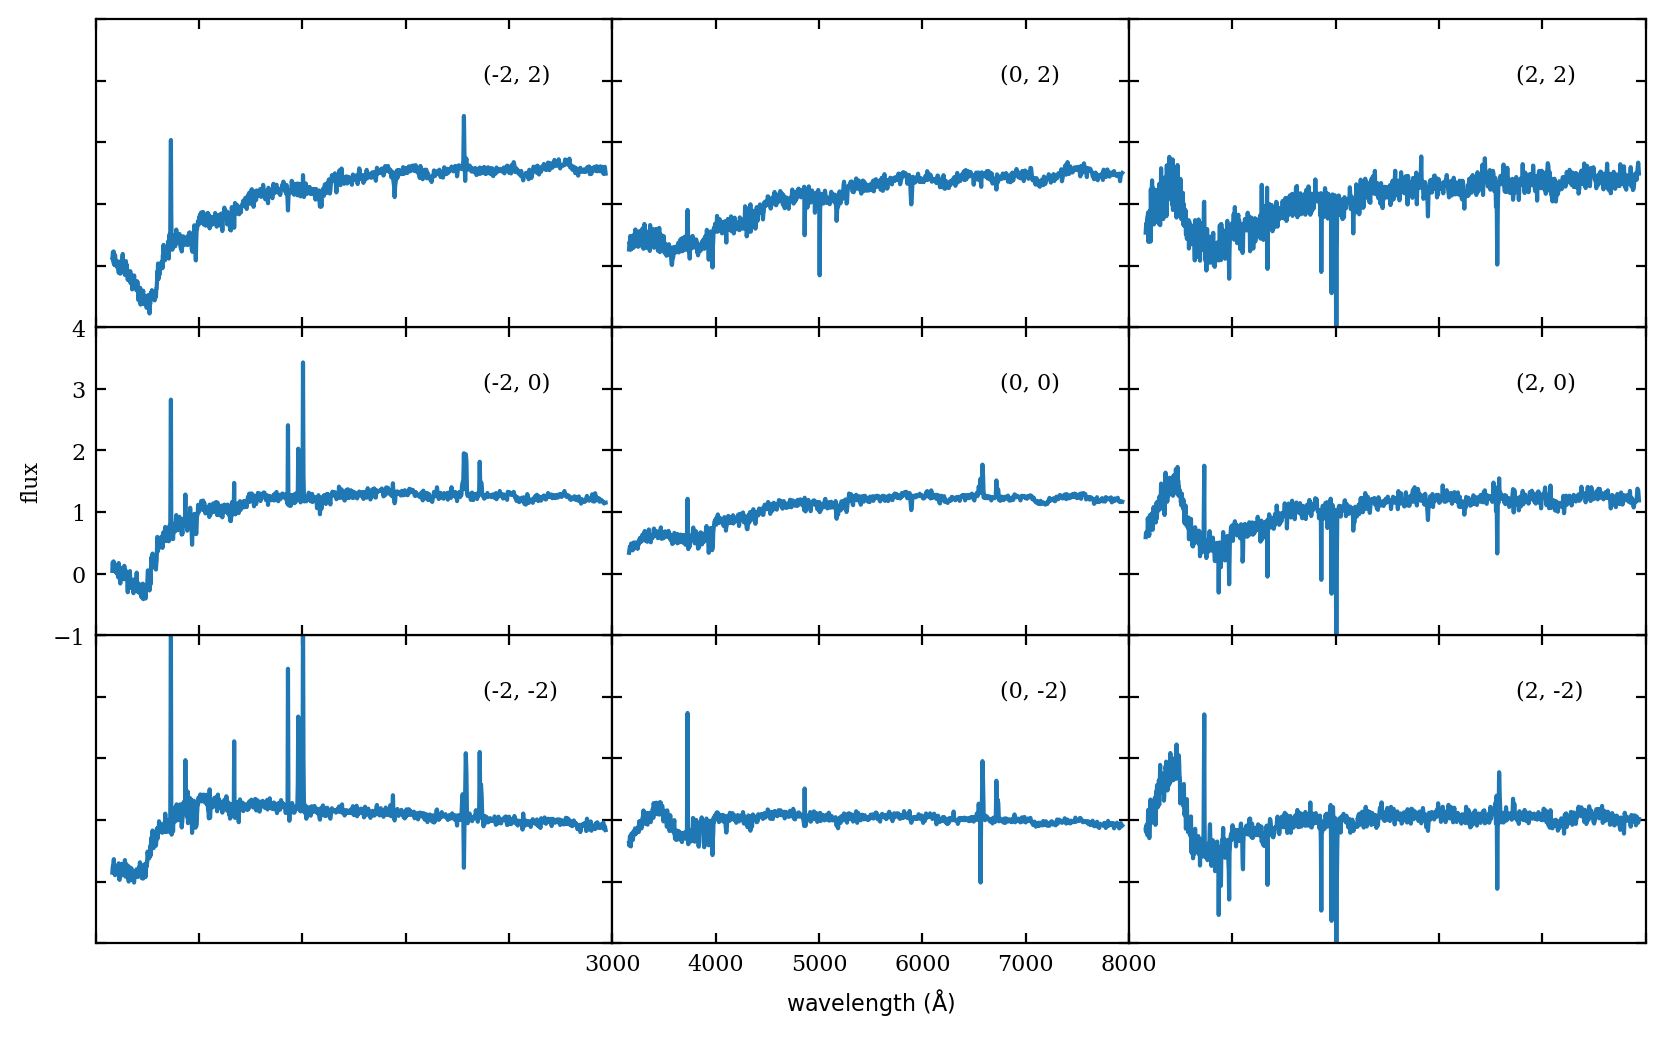

In [34]:
# plot results
with torch.no_grad():
    # sort latent parameters from most constrained to least constrained
    testspec = dataset[:][0]
    recon, mu, logvar = model(testspec)
    zorder = np.argsort(np.mean(logvar.numpy(), axis=0))

    fig = plt.figure(figsize=(10, 6))
    fig.subplots_adjust(hspace=0, wspace=0)
    parvalues = [-2.,0.,2.]
    for i, z1 in enumerate(parvalues):
        for j, z2 in enumerate(parvalues):
            # get z1 to vary left to right, z2 bottom to top
            ax = fig.add_subplot(3, 3, (2-j)*len(parvalues)+i+1)

            z = np.zeros((1,2), dtype=np.float32)
            z[0, zorder] = z1, z2 # set z1 is more constrained of the two latent parameters
            spectrum = model.decode(torch.tensor(z))
            ax.plot(wavelengths, meanspectrum+spectrum.numpy()[0,:])
            ax.text(6750, 3, '(%i, %i)' % (z1,z2))

            ax.set_xlim(3000, 8000)
            ax.set_ylim(-1, 4)

            if i == 0 and j == 1:
                ax.set_ylabel('flux')
            else:
                ax.yaxis.set_major_formatter(plt.NullFormatter())
            if j == 0 and i == 1:
                ax.set_xlabel(r'${\rm wavelength\ (\AA)}$')
            else:
                ax.xaxis.set_major_formatter(plt.NullFormatter())
plt.show()

The spectra above are generated from our variational autoencoder. As mentioned, the encoder was limited to two components (2D compressed latent space). As neurons are progressively activated in the latent space, we generate a smooth transition from spectra consistent with quiscent to star-forming galaxies. The numbers in each panel indicate the activation value of the two neurons in the latent space.

I'm basically reconstructing spectra that i've never seen. These galaxies do not exist but they really look like the one that do exist. This is the problem of cloning the data. This works with compressing, learning features, introduce random sampling and then reexpanding into the original space. In this sense they do not exist: they are cloned data.

More examples in astronomy:

- Radio galaxies: https://arxiv.org/abs/2311.08331
- Gravitational-wave noise transients: https://arxiv.org/abs/2303.05986
- Time domain astronomy: https://arxiv.org/abs/2312.16687
- Large scale structures: https://arxiv.org/abs/2403.02171
- Stars from a survey: https://arxiv.org/abs/2405.08703

... and many more

## Generative Adversarial Networks (GANs) <a class="anchor" id="four"></a>

Finally here's a brief discussion on GANs, which are one of latest innovation in deep learning.

GANs are pure evil, see https://thispersondoesnotexist.com/

But they are also brilliant, incredibly useful, and relatively new ([Goodfellow et al 2014](https://papers.nips.cc/paper/5423-generative-adversarial-nets.pdf)). The idea builds logically on autoencoders: it basically puts two AIs one against the other.
1. We have a generator (like the decoder part of an autoencoder) that can produce fake data (e.g., an image). 
2. Then we have a discriminator (a standard binary classifier) that tries to distinguish fake data from real.  
3. Then the generator learns to produce more and more accurate images to trick the discriminator -- without ever seeing any real images -- it just has the feedback from the discriminator.
4. We are pitting AIs against themselves to make them stronger. What could possibly go wrong, right?

The generator has a training set and learns how to create other images. The discriminator learns to discriminate between true and fake images and it also has a training set of true images. The loss functions are set up so that the loss function of the generator want the loss function of the discriminator to go up so it want to make images better and better so that the discriminator gets fooled. Instead, the discriminator fights back and wants to learn how to discriminate the two images.

For more, see
https://towardsdatascience.com/understanding-generative-adversarial-networks-gans-cd6e4651a29

Astronomy has seen some interesting uses of GANs in recent years.  For example:
    
- Upsampling of galaxy images https://arxiv.org/abs/1702.00403    
- More galaxies (lucky them! they have lots of data) https://arxiv.org/abs/2211.04488
- Hydro simulations https://arxiv.org/abs/2211.05000
- GW bursts https://arxiv.org/abs/2103.01641
- Cherenkov Telescope https://arxiv.org/abs/2211.15807
- Stellar core collapse https://arxiv.org/abs/2408.02895

... and more

## Large language models (LMMs)

LMMs (think chatGPT) didn't exist when I started teaching this class, and now are taking over the world. 

**GPT = generative pretrained transformers**

A GPT is a (very!) complicated mathematical function that predicts, given a piece of text, what word should come next.

[GPT-4 by OpenAI](https://en.wikipedia.org/wiki/GPT-4) allegedly has **1.76 trillion parameters**. The dataset? It's **the entire internet**.

The revolutionary paper that started the LMM revolution: https://arxiv.org/abs/1706.03762 (by Google)

An recent applications of transformers to the gravitational-wave detection problem (maybe the first one?), with contributions by Federico De Santi in my group: https://arxiv.org/abs/2505.02773

This video is great:

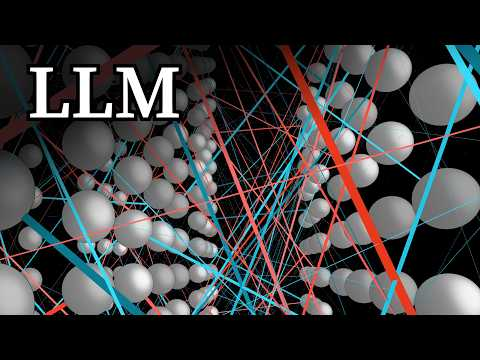

In [35]:
from IPython.display import YouTubeVideo
YouTubeVideo('LPZh9BOjkQs', width=1000, height=500)

## Flows and SBI

One of the coolest thing we really like but didn't have time to talk about are the so-called **Masked Autoregressive Flows**, introduced by [Papamakarios et al (2017)](https://arxiv.org/abs/1705.07057). MAF are the latest answer to the long-standing problem of density estimation (remember how tricky it can be to choose the number of bins? Now tackle that problem with the full power of deep learning!). The idea is that you learn density estimation by learning transformation between distributions. You have a dataset and start from a base distribution (a square, a gaussian) and then you learn a set of invertible flow distribution that mimic the one that you actually have starting from the base distribution.

Flows enter directly what's called **"Simulation-based inference"** or "likelihood-free inference". Remember you might want to become a Bayesian (don't ask me why at the end of the class!). Is deep learning helpful? Totally, and even better, you can sample posteriors in cases where you can't even write down the likelihood (perhaps because it's not analytic, like gappy data, data with unmodeled instrumental artifacts, etc). This is the deep learning solution of sampling that is you use a neural network to learn posterior distribution. All the network does is to simulate fake datas and you have the true data (including noise processes) and the network learns to match them. The closer the fake data are to true data, the better the parameters are. The reason that this is really powerful is that you don't need to write down the likelihood: you get the posterior distribution withouth even writing down the likelihood. While in MCMC the first thing you need to code up the likelihood and we always assume it's gaussian. There are cases though when you know the noise process but there is no an analytical expression of the noise.

In gravitational-wave physics, we're now really pushing the SBI idea. Current data analysis is done with either MCMCs or (mostly) nested sampling. But IMO everyone will switch to SBI eventually, it's just better. Some examples
- Dingo code: https://arxiv.org/abs/2106.12594 (used by PhD student Alice Spadaro in my group)
- Peregrine code: https://arxiv.org/abs/2304.02035 (used by postdoc Philippa Cole in my group, [here](https://arxiv.org/abs/2505.16795))
- Ringdown application https://arxiv.org/abs/2404.11373 (new implementation by postdoc Costantino Pacilio in my group using [the SBI package](https://github.com/sbi-dev/sbi))


Another tool you may be interested in: https://astronn.readthedocs.io/en/latest/index.html


<div class="alert alert-block alert-warning"> 
    
**Very personal opinion / rant** 
    
AI is revolutionary because of the scale of complexity it reached. If you think about it, even a linear fit is "generative AI", in the sense that you learned something from previous data and can predict on a new unseen instance. But we humans don't find it surprising ("a computer might be faster, but I could do it as well"). LMMs have now reached a level of complexity that is comparable (or beyond actually) to that of our brains. It's the scale of the novelty that is revolutionary, not the novelty itself. Somehow humanity has been writing texts for a millennia, all that text is there and can be reproduced.

For instance: it turns our LMMs are really good at translating between languages. They weren't trained for that, but the information is there in all the text humans have written, and LMMs picked it up. Translating is a challenging task for a human (how many languages do you know?); that's what I mean by the scale of complexity.       

</div>



### ... and we're done.

I'm not saying that you are ready for a data science job after these two lectures on deep learning, but you now know more than the majority of astrophysicists that talk about neural networks, and you have used the two big codes. There are tons of useful videos, tutorials, and online courses that can take you further if you are interested in deep learning.




## Extra material

The repository has two additional lectures on time series data which, unfortunately, I didn't have time to cover. 

## Time to get your hands dirty. Your first neural network; pick your favourite.


For the last coding assignment, you'll need to implement a neural network. We'll look at a relatively simple binary classification problem. Here below are three options; completing one of them for the exam is enough

### Tasks:

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

2. Decide your optimization metric.

3. Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

4. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

5. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

6. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.


### A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

### Datasets:

You can choose one of these three problems:

- **1. Galaxies vs quasars (but with neural networks)** Go back to our SDSS data we've used in Lecture 19. We had color differences, and the task was to classifty quasars vs galaxies. Repeat that task with a neural network.

- **2. Can a computer learn if we're going to detect gravitational waves? (but with neural networks)** Go back to the SNR classifier for gravitational wave events, same data we've used in Lecture. We had properties of black hole binaries, and the task was to classify. Repeat that task with a neural network.

- **3. The HiggsML challenge** Branching out of astrophysics, let's mess around with a dataset of simulated but  realistic events from the ATLAS particle detector at CERN.
    - Data are at `solutions/higgs.tar.gz` (you need to uncompress with `tar -czvf`)
    - There are $N_{\rm samples} = 2.5\times 10^5$ entries with $N_{\rm features}=30$ features each. 
    - The taks is that of classifying these features against a set of labels, which are either `s` (source) or `b` (background).
    - For some info on both the physics and the dataset see [this document](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf); includes a description of the features and how data have been padded (-999) for missing values.
    - This dataset was part of a challenge that run on Kaggle in 2014: https://higgsml.ijclab.in2p3.fr/ 



#### (On dataset 2, this is the best I could do...)

Together with Alberto Vecchio and Geraint Prattent, I tackled this gravitational-wave classification problem using neural networks in this paper: [arXiv:2007.06585](https://arxiv.org/abs/2007.06585). 
- In the paper we reached an accuracy (true positive + true negative / total) of $98.4\%$. The data you're using are those of the green curve in Fig 2 of that paper. Could you do better? If yes, please tell me how! 
- I should have really put a figure with my ROC in that paper but I didn't!

[My exploration (1)](https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/solutions/S22_galaxyquasar2.ipynb)

[My exploration (2)](https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/solutions/S22_SNRclassifier2.ipynb)

(Sorry I don't have 3...)


### Feedback!

Please remember the official University questionnaires (important), and my feedback form (if you find 5 mins, thanks):

https://forms.gle/JxNTfWid3qFBfVEv9

### Exams

Exam guidelines are available [here](https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/exams.md).

## Ideas for Master's thesis projects with me and my research group

- *Theory* of black-hole binaries, post-Newtonian approximation to General Relativity (gauge effects in gravity, spin-orbit interactions)
- *Astrophysics* of gravitational-wave sources (how do merging black holes and neutron stars form from their stellar progenitors?)
- *Data analysis* of gravitational-wave detectors (LIGO/Virgo today, Einstein Telescope and LISA tomorrow)
- ...with or without some statistics and machine learning. 


Work from some MSc thesis project I supervised that ended up in published papers
- Cecilia Fabbri (then PhD in Nottingham, UK): https://arxiv.org/abs/2501.17233
- Alessandro Pedrotti (then PhD in Marseille): https://arxiv.org/abs/2504.10482
- Francesco Nobili (then PhD in Como, Italy): https://arxiv.org/abs/2504.17021
- Alessandro Santini (then PhD at Max Planck AEI, Germany): https://arxiv.org/abs/2308.12998
- Giovanni Cavallotto (then researcher here at Bicocca): https://arxiv.org/abs/2304.04801
- Maciej Dabrowny (then data scientist): https://arxiv.org/abs/2106.12541
- Matteo Boschini (then PhD in my group): https://arxiv.org/abs/2307.03435
- Alice Spadaro (then PhD in my group): https://arxiv.org/abs/2306.03923
- Luca Reali (then PhD at Johns Hopkins, USA): https://arxiv.org/abs/2005.01747
- Riccardo Barbieri (then PhD at Max Planck AEI, Germany): https://arxiv.org/abs/2004.02894

[These](https://davidegerosa.com/group/) are the amazing folks I'm working with. Come have a chat, we are always looking for new friends.

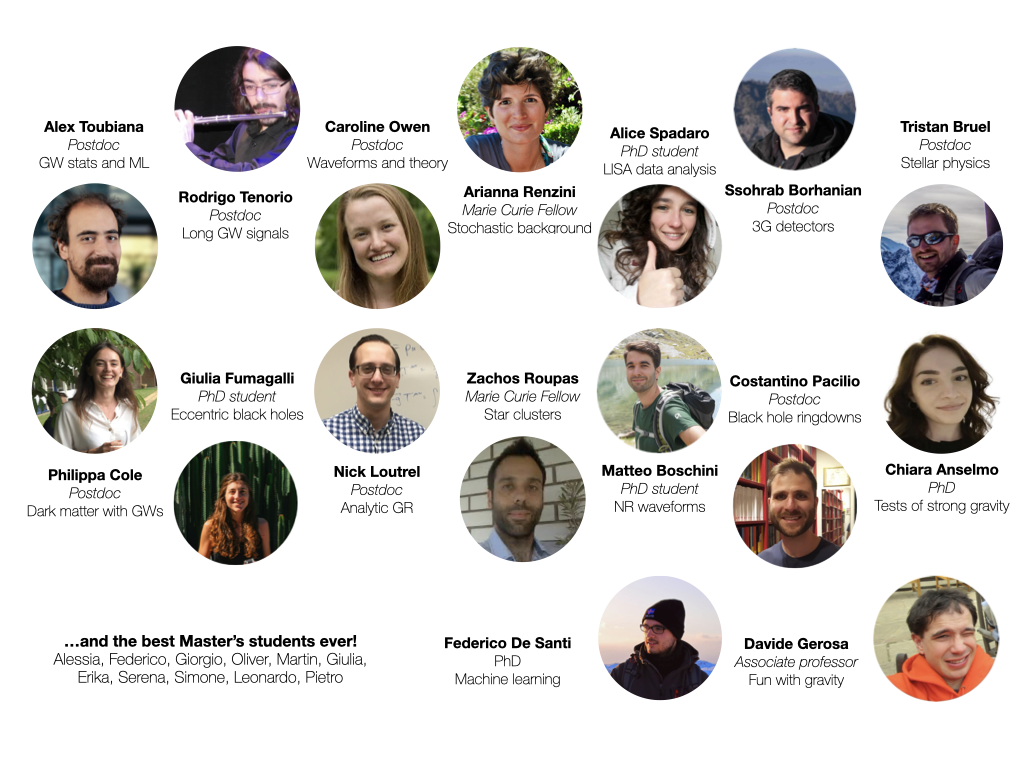

----

# That's all folks!

![](https://imgs.xkcd.com/comics/data_trap.png)

But hopefully now you know what do to with data (at least a bit).